# Objective : Variable Importance Analysis for LLM Performance

## 1. Introduction & Setup
The goal of this notebook is to identify and quantify which design characteristics (architecture, compute, data) most influence the performance of large language models across different benchmarks.

Given that our dataset is extremely small ($n=77$), our analytical strategy is based on **linear models with strong regularization** combined with **SHAP (SHapley Additive exPlanations)**, ensuring that importance explanations are robust and not mere mathematical artifacts of sample noise.

In [1]:
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Library imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold

# Interpretation
import shap

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# Data loading
# ==========================================
#df = pd.read_excel('../data/processed/dataset_clean_log.xlsx')
df = pd.read_excel('../data/processed/dataset_clean.xlsx')
print(f"Dataset dimensions: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset dimensions: (77, 61)
Columns: ['model', 'organization', 'publication_date', 'domain', 'task', 'parameters', 'training_flops', 'training_dataset', 'dataset_size', 'confidence', 'link', 'reference', 'organization_type', 'country', 'notability_criteria', 'epochs', 'base_model', 'model_accessibility', 'training_code_accessibility', 'numerical_format', 'open_weights', 'model_key', 'id', 'model_hf', 'precision', 'model_type', 'weight_type', 'architecture', 'average_score', 'has_chat_template', 'ifeval_name', 'ifeval', 'ifeval_normalized', 'bbh_name', 'bbh', 'bbh_normalized', 'math_name', 'math', 'math_normalized', 'gpqa_name', 'gpqa', 'gpqa_normalized', 'musr_name', 'musr', 'musr_normalized', 'mmlu_pro_name', 'mmlu_pro', 'mmlu_pro_normalized', 'not_available_hub', 'is_moe', 'official_provider', 'upload_date', 'submission_date', 'generation', 'base_model_hf', 'license', 'hub_likes', 'parameters_billions', 'co2_cost', 'model_key_name', 'model_key_base']


## 2. Benchmark Correlation Analysis

Before modeling, we need to understand the behavior of our target variables (the benchmarks). If scores across different benchmarks (e.g., `ifeval`, `math`, `bbh`) are highly correlated with each other, it means they measure similar latent capabilities in the model — or that a larger model simply improves on everything simultaneously.

**Implications of Multicollinearity:**  
High correlation is dangerous with $n=77$, both in predictor features and target variables. In features, it causes linear model coefficients to become unstable (high variance).

**Strategy:**
1. Visualize the correlation to understand whether findings can be generalized.
2. To mitigate collinearity in predictor variables, we will use **Ridge Regression ($L_2$)**, which penalizes large coefficients and distributes importance evenly among correlated variables, stabilizing the model.

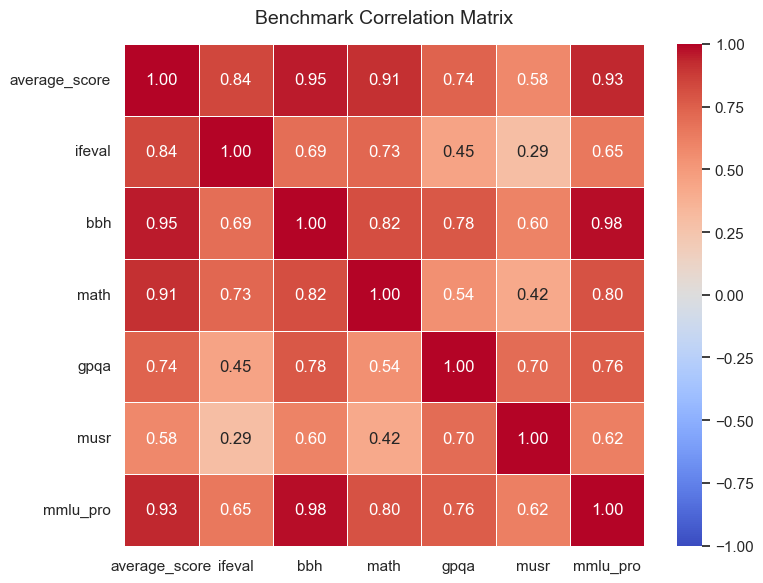

In [2]:
# Select benchmark columns present in the dataset
benchmarks = ['average_score', 'ifeval', 'bbh', 'math', 'gpqa', 'musr', 'mmlu_pro']

# Pearson correlation matrix
corr_matrix = df[benchmarks].corr()

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Benchmark Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 3. Preprocessing & Data Confidence Management

For a mathematical model to consume our dataset, two critical transformations are needed:

1. **One-Hot Encoding for Categorical Variables:** We convert features like `architecture` or `model_type` into binary columns (0 and 1), avoiding the imposition of an unrealistic numerical order between categories.
2. **Transforming `data_confidence` into `sample_weight`:** Our dataset has entries with varying levels of reliability ('Confident' and 'Speculative'). To prevent uncertain data from skewing our model in this small sample, we map this variable mathematically: confirmed observations receive weight ($w_i = 1.0$) and speculative ones receive a penalized weight ($w_i = 0.5$). This vector is injected into the algorithm's loss function during fitting.

In [3]:
# Feature definition
features_num = ['parameters', 'training_flops', 'dataset_size', 'epochs']
features_cat = ['organization_type', 'architecture', 'model_type']

df_clean = df.copy()

# df_clean[features_num] = df_clean[features_num].fillna(df_clean[features_num].median())
df_clean[features_cat] = df_clean[features_cat].fillna('Unknown')

cols_to_transform = [col for col in features_num if col in df_clean.columns]

for col in cols_to_transform:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    if df_clean[col].min(skipna=True) >= 0:
        df_clean[col] = np.log1p(df_clean[col])    
    else:
        print(f" Warning: '{col}' contains negative values")

# Sample weight vector creation
# Mapping: 'Confident' -> 1.0, 'Speculative' -> 0.5
weight_mapping = {'Confident': 1.0, 'Speculative': 0.5}
df_clean['observation_weight'] = df_clean['confidence'].map(weight_mapping).fillna(0.5)

# X, y separation (usando df_clean, que ahora SÍ tiene los logaritmos)
X = df_clean[features_num + features_cat]
y = df_clean['average_score']
weights = df_clean['observation_weight']
groups = df_clean['model']  # Variable for GroupKFold

# Preprocessing pipeline (Scaling numerics + One-Hot Encoding categoricals)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
    ]
)

# Fit the preprocessor and transform X
X_processed = preprocessor.fit_transform(X)
feature_names = list(preprocessor.named_transformers_['num'].get_feature_names_out()) + \
                list(preprocessor.named_transformers_['cat'].get_feature_names_out())

X_processed_df = pd.DataFrame(X_processed, columns=feature_names, index=df_clean.index)

print(f"Number of features after preprocessing: {X_processed_df.shape[1]}")
print(f"Weight distribution: {df_clean['observation_weight'].value_counts().to_dict()}")

Number of features after preprocessing: 23
Weight distribution: {1.0: 70, 0.5: 7}


## 4. Robust Modeling for Small & Grouped Datasets

With only 77 observations and multiple features, complex models like Random Forest would memorize the data (overfitting). We opt for **Ridge Regression ($L_2$)** which penalizes large coefficients, stabilizing the model.

**Group-Based Cross-Validation (GroupKFold):**  
Crucially, to avoid *data leakage*, we cannot do random splits. Different iterations of the same model family (e.g., indicated by `modelo_epoch`) share underlying characteristics. Mixing models from the same family into training and test sets would artificially inflate performance. We use `GroupKFold` to ensure that entire families are isolated in the test set, forcing the model to learn patterns that generalize to completely new model families.

In [4]:
# Initialize GroupKFold to isolate model families (modelo_epoch)
gkf = GroupKFold(n_splits=5)

# Explicitly generate cross-validation splits based on groups
cv_splits = list(gkf.split(X_processed_df, y, groups=groups))

# Initialize RidgeCV passing custom splits
model = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=cv_splits)

# Fit the model explicitly integrating sample_weight
model.fit(X_processed_df, y, sample_weight=weights)

print(f"Best alpha selected by GroupCV: {model.alpha_:.4f}")
print(f"R^2 Score on full dataset: {model.score(X_processed_df, y, sample_weight=weights):.4f}")

Best alpha selected by GroupCV: 17.4753
R^2 Score on full dataset: 0.6976


## 5. Variable Importance Extraction & SHAP Analysis

Although Ridge provides direct coefficients ($\beta$), we use **SHAP** for a key reason: linear coefficients indicate the theoretical slope, but **SHAP combines the coefficient with the actual distribution of our data**.

The SHAP formula for linear models distributes the model effect as:
$$\phi_j(x) = \beta_j (x_j - E[x_j])$$

This tells us exactly how much a specific feature (e.g., FLOPs) contributed to increasing or decreasing the score *for the concrete models in our sample*. It reveals not just importance magnitude but also directionality, and whether asymmetric effects exist due to data density.

Top 10 features by absolute coefficient:
                                       Feature  Coefficient  Absolute_Importance
                 architecture_Qwen2ForCausalLM     4.238572             4.238572
                                training_flops     3.482447             3.482447
                                  dataset_size     2.845451             2.845451
                                    parameters     1.820761             1.820761
                 architecture_LlamaForCausalLM    -1.734250             1.734250
                    organization_type_Industry     1.594970             1.594970
model_type_fine-tunedondomain-specificdatasets     1.245459             1.245459
                         model_type_pretrained    -1.245361             1.245361
           organization_type_Industry,Academia    -1.121496             1.121496
                           model_type_â “other    -0.991450             0.991450


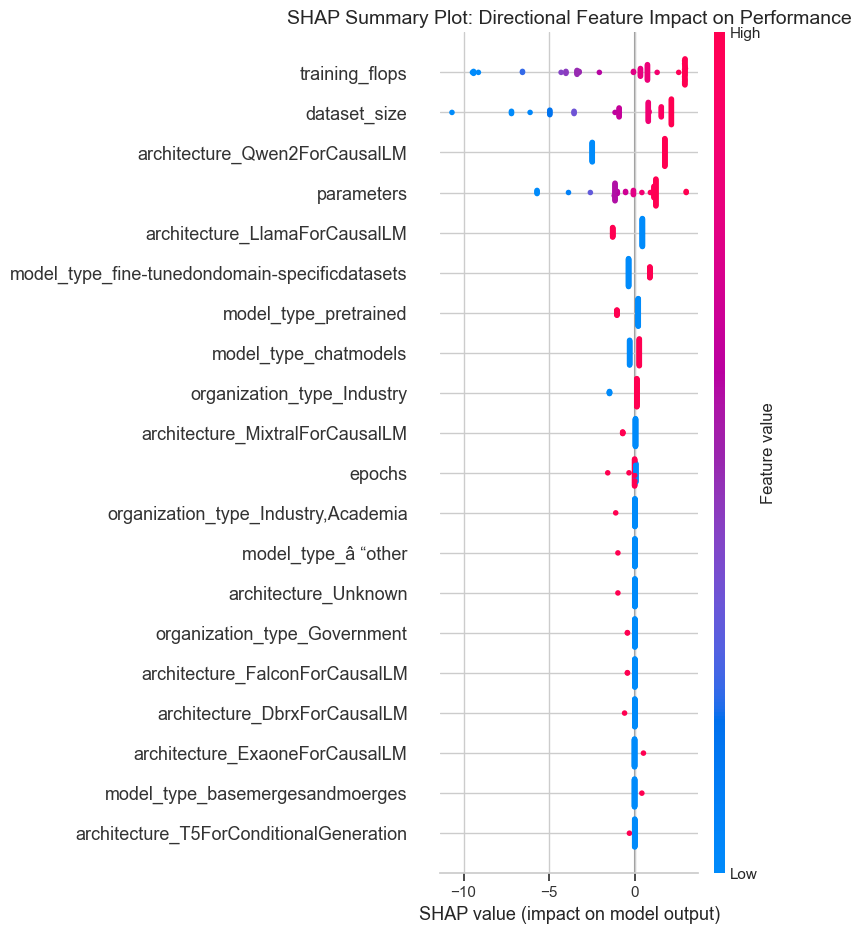

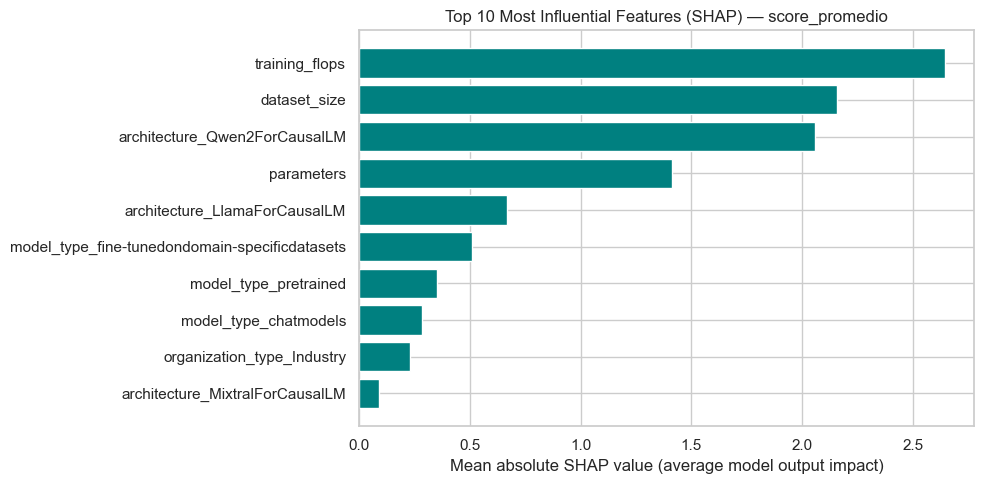

In [5]:
# Native model importance (Absolute Coefficients)
coef_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_,
    'Absolute_Importance': np.abs(model.coef_)
}).sort_values(by='Absolute_Importance', ascending=False)

print("Top 10 features by absolute coefficient:")
print(coef_importance.head(10).to_string(index=False))

# SHAP Analysis
# LinearExplainer is ideal for linear regressions
explainer = shap.LinearExplainer(model, X_processed_df)
shap_values = explainer.shap_values(X_processed_df)

# Visualization 1: SHAP Summary Plot (directional impact)
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Directional Feature Impact on Performance", fontsize=14)
shap.summary_plot(shap_values, X_processed_df, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

# Visualization 2: Top 10 Variables by Mean SHAP Magnitude (Bar Chart)
shap_sum = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': shap_sum
}).sort_values(by='SHAP_Importance', ascending=True).tail(10)

plt.figure(figsize=(10, 5))
plt.barh(shap_df['Feature'], shap_df['SHAP_Importance'], color='teal')
plt.xlabel("Mean absolute SHAP value (average model output impact)")
plt.title("Top 10 Most Influential Features (SHAP) — score_promedio")
plt.tight_layout()
plt.show()

## 6. Reusable Function (Benchmark Analysis Pipeline)

To optimize the workflow, the entire process has been encapsulated in a single function. This allows us to iteratively run this analysis by changing the target variable (`target_col`), automatically applying preprocessing, weighted modeling, and hermetic group separation (GroupKFold).

In [6]:
def analyze_benchmark_importance(df, target_col, features_num, features_cat, group_col='model'):
    """
    Full pipeline: Preprocessing, Robust weighted Modeling (Ridge) with GroupKFold,
    and SHAP importance extraction for a specific benchmark.
    
    Parameters
    ----------
    df           : pd.DataFrame — the full dataset
    target_col   : str — benchmark column to model (e.g. 'math', 'ifeval')
    features_num : list[str] — numeric feature column names
    features_cat : list[str] — categorical feature column names
    group_col    : str — column used to define groups for GroupKFold
    
    Returns
    -------
    model   : fitted RidgeCV model
    imp_df  : pd.DataFrame with top-10 features sorted by SHAP importance (descending)
    """
    print(f"--- Importance Analysis for: {target_col} ---")
    
    # 1. Clean data preparation
    temp_df = df.dropna(subset=[target_col, group_col]).copy()
    temp_df[features_num] = temp_df[features_num].fillna(temp_df[features_num].median())
    temp_df[features_cat] = temp_df[features_cat].fillna('Unknown')
    
    # 2. Variable definition
    temp_df['weight'] = temp_df['confidence'].map({'Confident': 1.0, 'Speculative': 0.5}).fillna(0.5)
    
    X = temp_df[features_num + features_cat]
    y = temp_df[target_col]
    w = temp_df['weight']
    groups = temp_df[group_col]
    
    # 3. Preprocessing
    prep = ColumnTransformer([
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
    ])
    X_trans = prep.fit_transform(X)
    cols = list(prep.named_transformers_['num'].get_feature_names_out()) + \
           list(prep.named_transformers_['cat'].get_feature_names_out())
    X_trans_df = pd.DataFrame(X_trans, columns=cols, index=temp_df.index)
    
    # 4. Generate group splits (GroupKFold)
    gkf = GroupKFold(n_splits=5)
    cv_splits = list(gkf.split(X_trans_df, y, groups=groups))
    
    # 5. Modeling (RidgeCV)
    model = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=cv_splits)
    model.fit(X_trans_df, y, sample_weight=w)
    
    print(f"  Best alpha: {model.alpha_:.4f} | R² (train): {model.score(X_trans_df, y, sample_weight=w):.4f}")
    
    # 6. SHAP
    explainer = shap.LinearExplainer(model, X_trans_df)
    shap_vals = explainer.shap_values(X_trans_df)
    
    # Plot 1: SHAP Summary (directional)
    plt.figure(figsize=(10, 5))
    plt.title(f"Directional Feature Impact (SHAP) — {target_col}")
    shap.summary_plot(shap_vals, X_trans_df, plot_type="dot", show=False)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Top 10 Bar Chart
    mean_shap = np.abs(shap_vals).mean(axis=0)
    imp_df = pd.DataFrame({'Feature': cols, 'Importance': mean_shap})\
               .sort_values(by='Importance', ascending=True).tail(10)
    
    plt.figure(figsize=(8, 4))
    plt.barh(imp_df['Feature'], imp_df['Importance'], color='darkorange')
    plt.xlabel("Mean Absolute SHAP Value")
    plt.title(f"Top 10 Features — {target_col}")
    plt.tight_layout()
    plt.show()
    
    return model, imp_df.sort_values(by='Importance', ascending=False)




## 7. Phase 1 Modeling: Individual Benchmark Analysis (Granular Approach)

As a first step, we model each benchmark individually. The intuition is to evaluate whether different cognitive capabilities (e.g., pure mathematics in `math` vs. format following in `ifeval`) require different design configurations or architectures.

We iterate over the 6 main benchmarks in our database. For each, we apply our robust pipeline:
1. **Preprocessing** (StandardScaler + OneHotEncoder)
2. **Group-Based Cross-Validation** (`GroupKFold` using `modelo_epoch` to avoid data leakage between model families)
3. **Weighted Ridge Regression ($L_2$)** weighted by data confidence (`confianza_datos`)
4. **SHAP Extraction** for a directional importance ranking

In [7]:
# Setup: Dictionary to store models and rankings for later consultation
individual_results = {}

print("Starting Phase 1: Training benchmark-specific models...\n")

Starting Phase 1: Training benchmark-specific models...



Training model for 'ifeval'...
--- Importance Analysis for: ifeval ---
  Best alpha: 13.2194 | R² (train): 0.4809


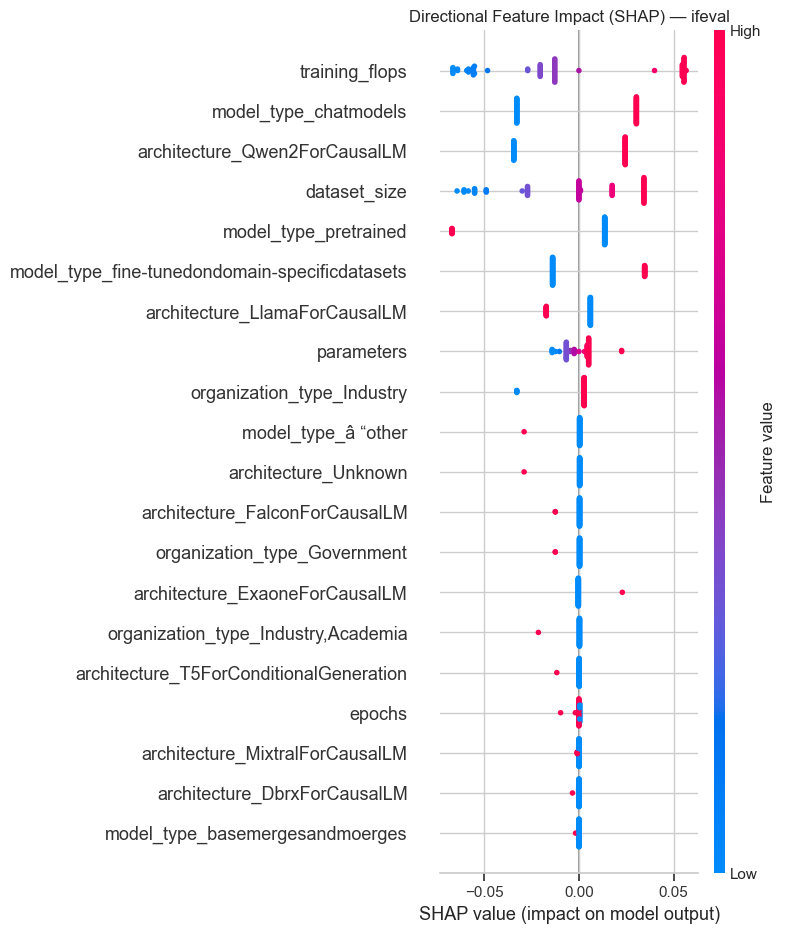

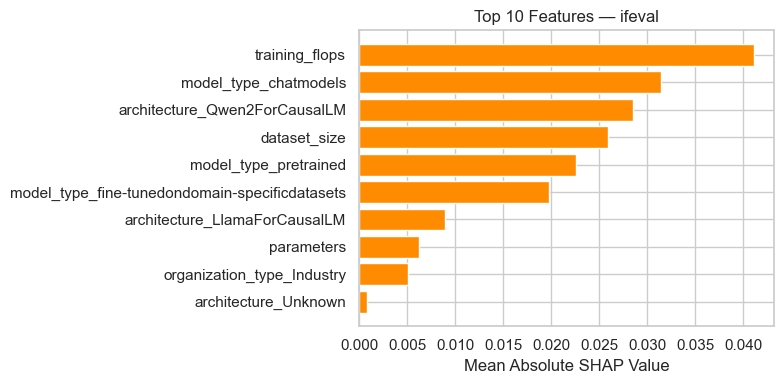

 Model for 'ifeval' completed.
--------------------------------------------------


In [8]:
# 1. Benchmark: IFEval
target = 'ifeval'
print(f"Training model for '{target}'...")

model_ifeval, ranking_ifeval = analyze_benchmark_importance(
    df=df,
    target_col=target,
    features_num=features_num,
    features_cat=features_cat,
    group_col='model'
)

# Store results
individual_results[target] = {
    'model': model_ifeval,
    'ranking': ranking_ifeval
}

print(f" Model for '{target}' completed.\n" + "-" * 50)

Training model for 'bbh'...
--- Importance Analysis for: bbh ---
  Best alpha: 53.3670 | R² (train): 0.5304


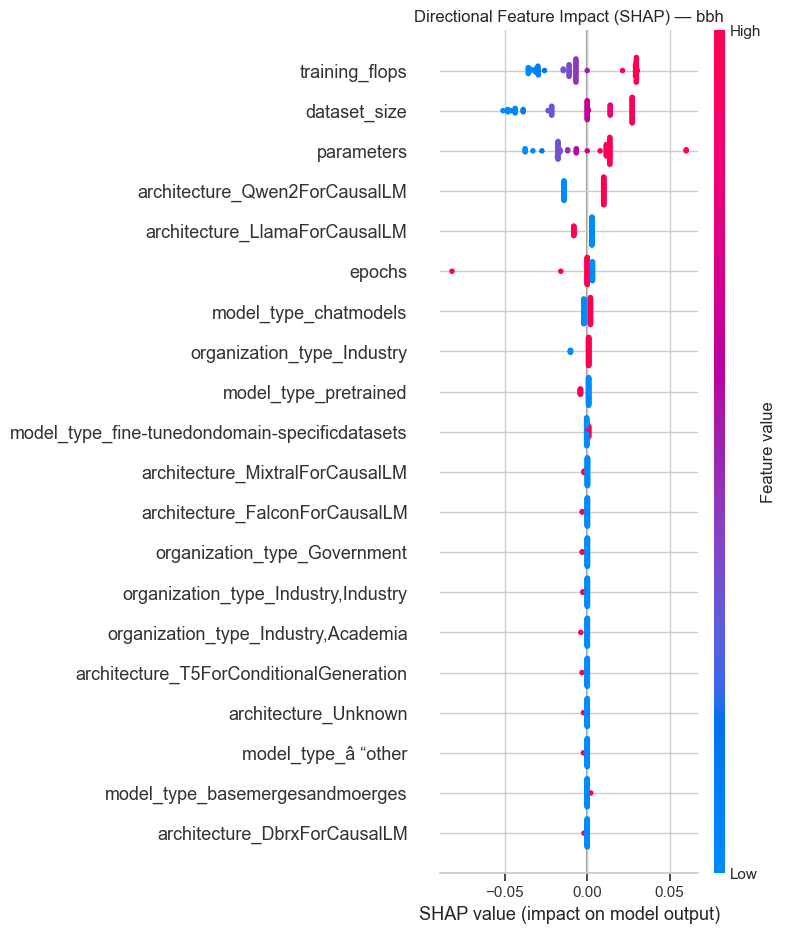

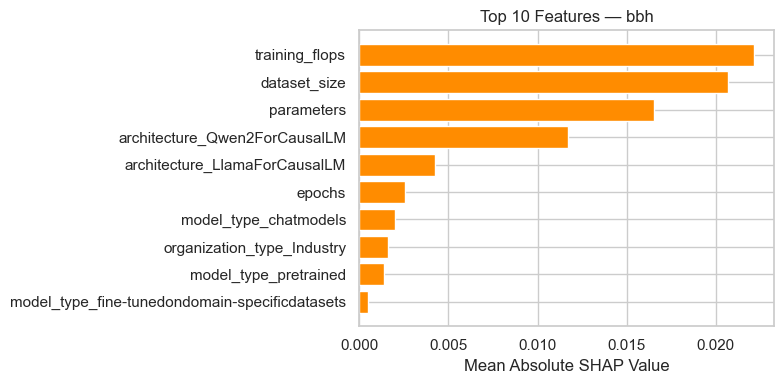

Model for 'bbh' completed.
--------------------------------------------------


In [10]:
# 2. Benchmark: BBH
target = 'bbh'
print(f"Training model for '{target}'...")

model_bbh, ranking_bbh = analyze_benchmark_importance(
    df=df,
    target_col=target,
    features_num=features_num,
    features_cat=features_cat,
    group_col='model'
)

# Store results
individual_results[target] = {
    'model': model_bbh,
    'ranking': ranking_bbh
}

print(f"Model for '{target}' completed.\n" + "-" * 50)

Training model for 'math'...
--- Importance Analysis for: math ---
  Best alpha: 0.0123 | R² (train): 0.8521


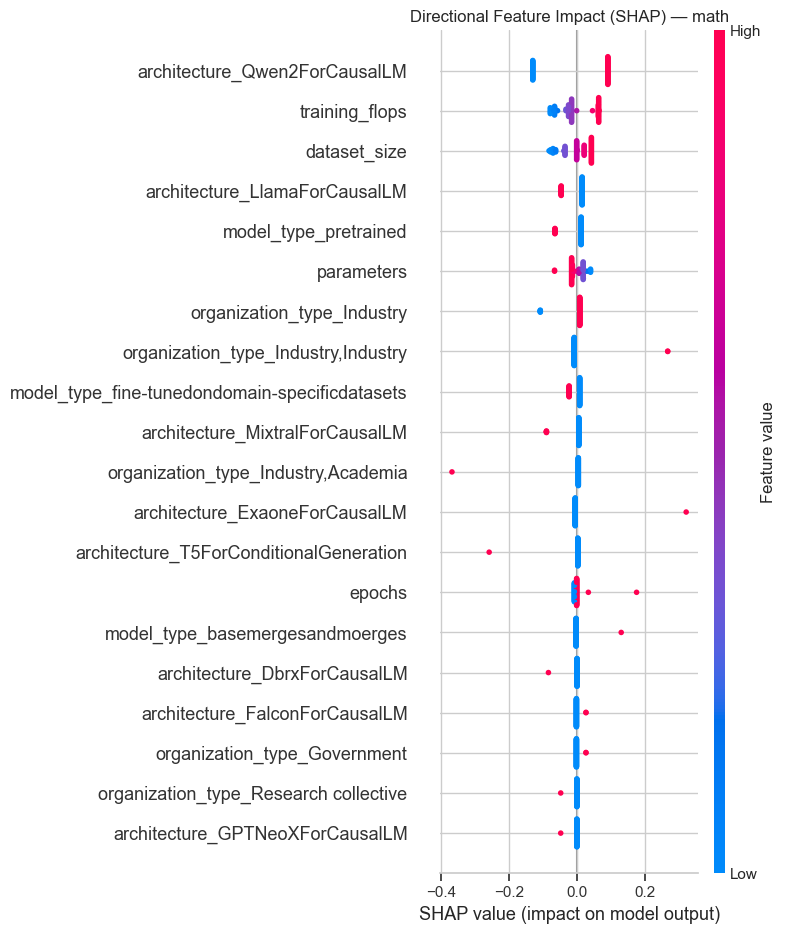

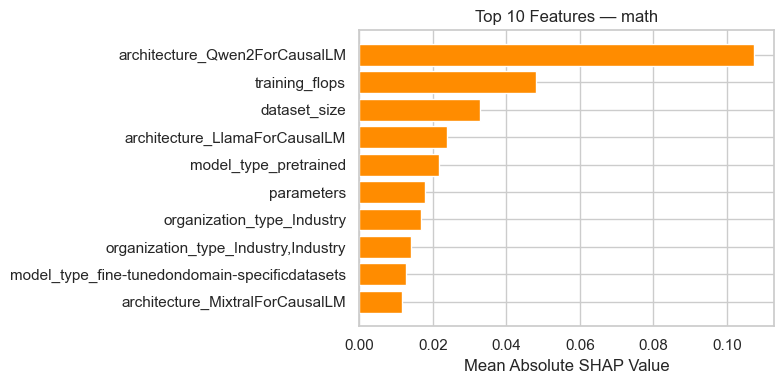

 Model for 'math' completed.
--------------------------------------------------


In [11]:
# 3. Benchmark: MATH
target = 'math'
print(f"Training model for '{target}'...")

model_math, ranking_math = analyze_benchmark_importance(
    df=df,
    target_col=target,
    features_num=features_num,
    features_cat=features_cat,
    group_col='model'
)

# Store results
individual_results[target] = {
    'model': model_math,
    'ranking': ranking_math
}

print(f" Model for '{target}' completed.\n" + "-" * 50)

Training model for 'gpqa'...
--- Importance Analysis for: gpqa ---
  Best alpha: 23.1013 | R² (train): 0.5104


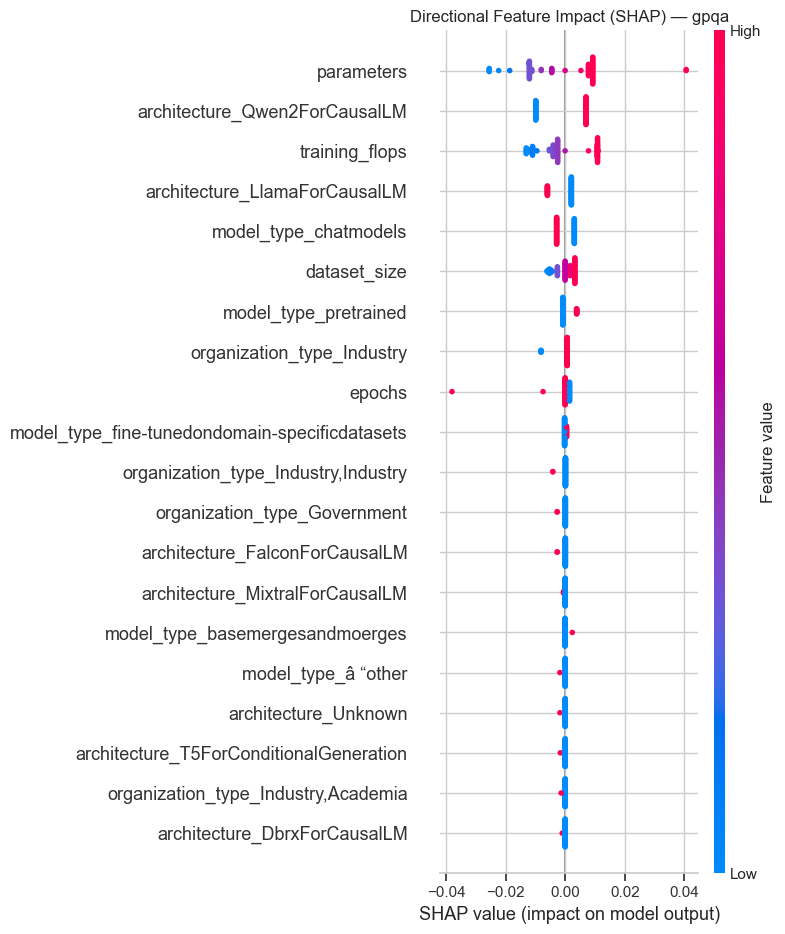

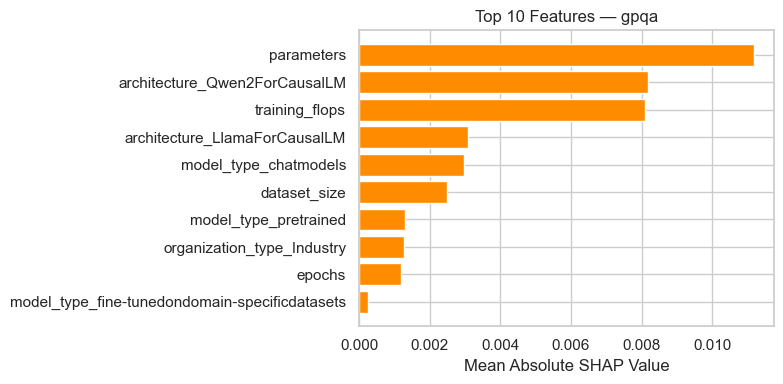

Model for 'gpqa' completed.
--------------------------------------------------


In [12]:
# 4. Benchmark: GPQA
target = 'gpqa'
print(f"Training model for '{target}'...")

model_gpqa, ranking_gpqa = analyze_benchmark_importance(
    df=df,
    target_col=target,
    features_num=features_num,
    features_cat=features_cat,
    group_col='model'
)

# Store results
individual_results[target] = {
    'model': model_gpqa,
    'ranking': ranking_gpqa
}

print(f"Model for '{target}' completed.\n" + "-" * 50)

Training model for 'musr'...
--- Importance Analysis for: musr ---
  Best alpha: 61.3591 | R² (train): 0.3582


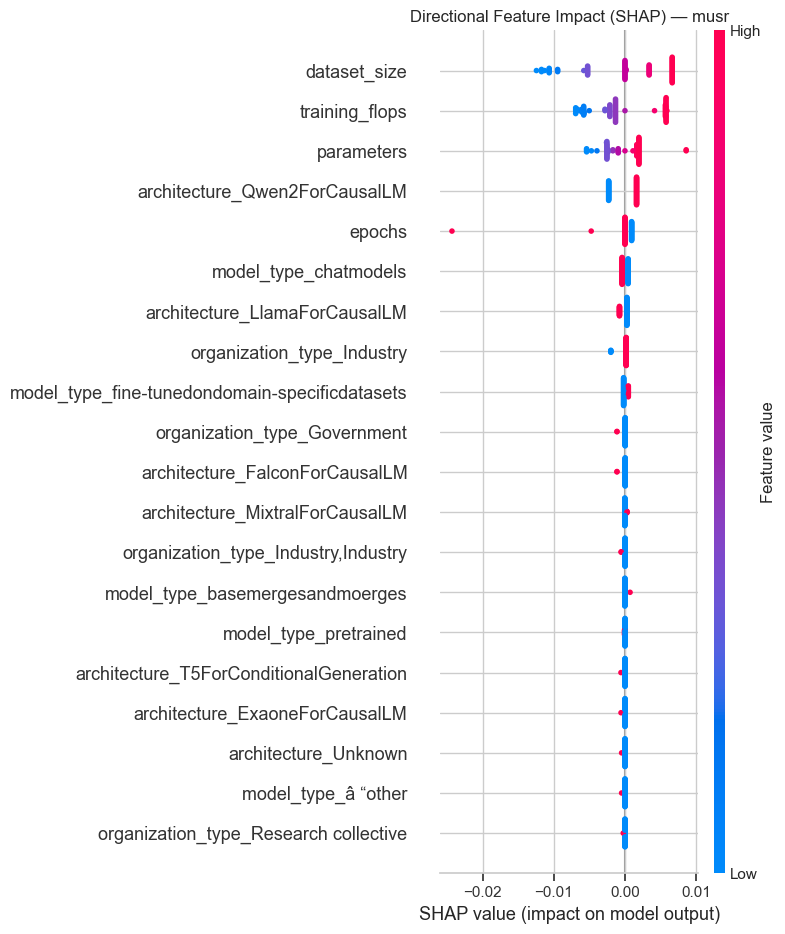

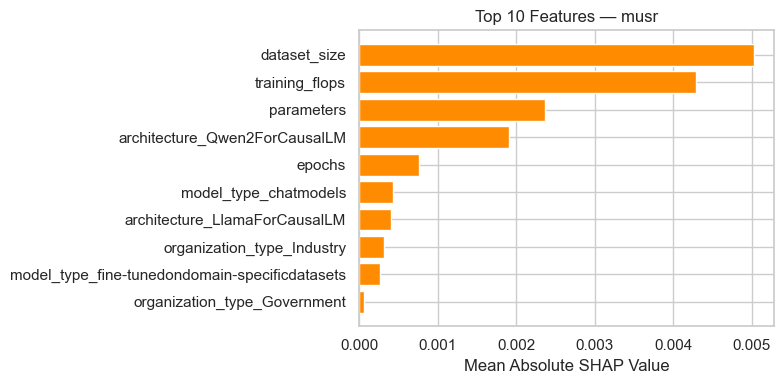

Model for 'musr' completed.
--------------------------------------------------


In [13]:
# 5. Benchmark: MuSR
target = 'musr'
print(f"Training model for '{target}'...")

model_musr, ranking_musr = analyze_benchmark_importance(
    df=df,
    target_col=target,
    features_num=features_num,
    features_cat=features_cat,
    group_col='model'
)

# Store results
individual_results[target] = {
    'model': model_musr,
    'ranking': ranking_musr
}

print(f"Model for '{target}' completed.\n" + "-" * 50)

Training model for 'mmlu_pro'...
--- Importance Analysis for: mmlu_pro ---
  Best alpha: 70.5480 | R² (train): 0.4846


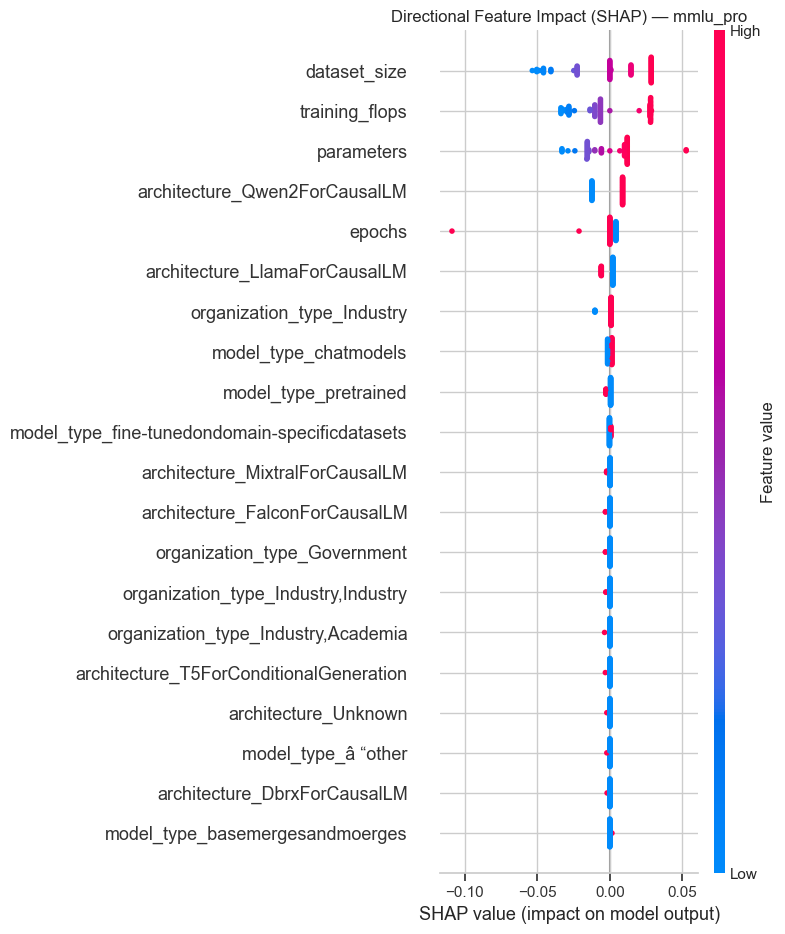

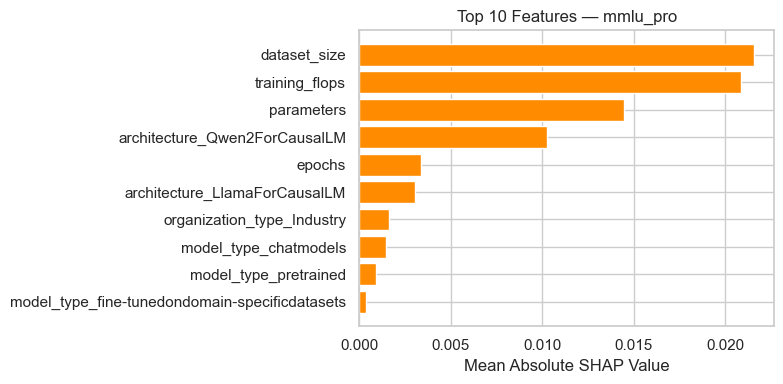

Model for 'mmlu_pro' completed.
--------------------------------------------------


In [14]:
# 6. Benchmark: MMLU-Pro
target = 'mmlu_pro'
print(f"Training model for '{target}'...")

model_mmlu_pro, ranking_mmlu_pro = analyze_benchmark_importance(
    df=df,
    target_col=target,
    features_num=features_num,
    features_cat=features_cat,
    group_col='model'
)

# Store results
individual_results[target] = {
    'model': model_mmlu_pro,
    'ranking': ranking_mmlu_pro
}

print(f"Model for '{target}' completed.\n" + "-" * 50)

## 8. Phase 2 Modeling: Consolidation & Redundancy Elimination 

After observing individual rankings and analyzing our **Correlation Heatmap**, we reach a fundamental conclusion: the benchmarks `bbh` and `mmlu_pro` are **highly positively correlated** and yield nearly identical predictor variable rankings.

**Mathematical & Scientific Justification:**  
With a restrictive dataset ($n=77$), maintaining separate predictive models for highly correlated benchmarks creates analytical redundancy and increases the risk of overfitting to the idiosyncratic noise of each specific test. In psychometrics and LLM evaluation, high correlation between tests indicates the presence of a **"Factor $g$"** (general reasoning capability).

Furthermore, because our ultimate goal is to build predictive models where these benchmarks act as our target variables ($Y$), standardizing them into relative scores (like Z-scores or Min-Max) would distort the target into a *relative ranking* tied only to this specific sample, stripping away the absolute scale. We need our models to predict actual benchmark performance, not a relative leaderboard position.

**Solution — The `reasoning_score` Target Variable:**  
We merge `bbh` and `mmlu_pro` into a single, unified target variable called `reasoning_score`. We compute this by calculating the **simple absolute mean** of the two benchmarks. This approach ensures that:
1. We consolidate the "Factor $g$" signal, reducing variance and noise.
2. We prevent Data Leakage and target distortion by preserving the original, absolute scale of the evaluation tests.
3. We maintain clear interpretability for our predictive model outputs (i.e., the predicted score represents the expected raw percentage accuracy).

In [15]:

benchmarks_to_merge = ["bbh", "mmlu_pro"]

df['reasoning_score'] = df[benchmarks_to_merge].mean(axis=1)

# Drop the original correlated columns
df = df.drop(columns=benchmarks_to_merge)

# Quick verification
print("Composite index preview:")
print(df[['model_hf', 'reasoning_score']].describe())
print()
print(df[['model_hf', 'reasoning_score']].head(10))

Composite index preview:
       reasoning_score
count        77.000000
mean          0.536324
std           0.134639
min           0.202405
25%           0.460245
50%           0.610255
75%           0.633618
max           0.656838

                              model_hf  reasoning_score
0                         Qwen/QwQ-32B         0.208947
1                 Qwen/QwQ-32B-Preview         0.618479
2                rootxhacker/apollo-7B         0.269205
3  LGAI-EXAONE/EXAONE-3.5-32B-Instruct         0.519886
4    meta-llama/Llama-3.3-70B-Instruct         0.612546
5                     Qwen/Qwen2.5-72B         0.638279
6            Qwen/Qwen2.5-72B-Instruct         0.644929
7                     Qwen/Qwen2.5-72B         0.638279
8            Qwen/Qwen2.5-72B-Instruct         0.644929
9                     Qwen/Qwen2.5-32B         0.628794


## 9. Phase 2 Modeling: SHAP Analysis on the Composite Variable

Now that we have created `reasoning_score`, we apply the same Ridge + SHAP pipeline to this new composite variable. This allows us to understand which design characteristics most influence **general reasoning capability** (the latent factor represented by the merged index), rather than a single benchmark.

Running analysis on composite variable: reasoning_score

--- Importance Analysis for: reasoning_score ---
  Best alpha: 61.3591 | R² (train): 0.5123


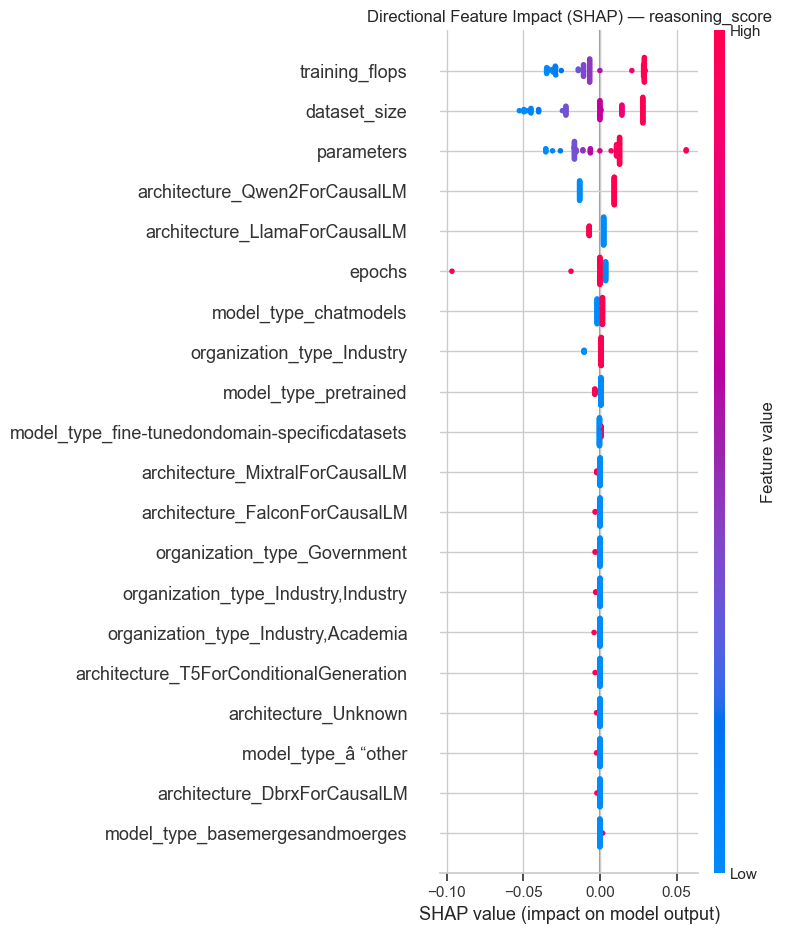

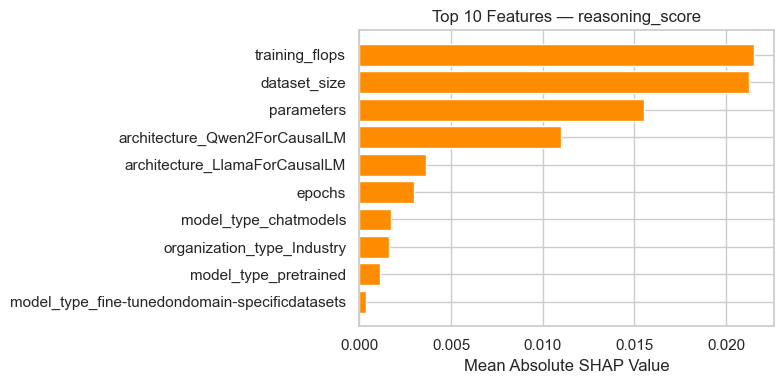


Top features for the reasoning composite index:
                                       Feature  Importance
                                training_flops    0.021528
                                  dataset_size    0.021242
                                    parameters    0.015509
                 architecture_Qwen2ForCausalLM    0.010981
                 architecture_LlamaForCausalLM    0.003609
                                        epochs    0.002996
                         model_type_chatmodels    0.001719
                    organization_type_Industry    0.001603
                         model_type_pretrained    0.001117
model_type_fine-tunedondomain-specificdatasets    0.000391


In [16]:
# ==========================================
# SHAP Analysis on the composite variable
# ==========================================

print("Running analysis on composite variable: reasoning_score\n")

model_reasoning, ranking_reasoning = analyze_benchmark_importance(
    df=df,
    target_col='reasoning_score',
    features_num=features_num,
    features_cat=features_cat,
    group_col='model'
)

print("\nTop features for the reasoning composite index:")
print(ranking_reasoning.to_string(index=False))

In [17]:
# ==========================================
# Exportar a Excel
# ==========================================

nombre_archivo = "dataset_merge.xlsx"

df.to_excel(nombre_archivo, index=False, sheet_name='Composite_Index')



## 10. Summary 

### What we have accomplished in this notebook:
1. **Correlation Analysis** — identified highly correlated benchmarks (`bbh`, `mmlu_pro`) suggesting a general reasoning factor.
2. **Robust Pipeline** — Ridge Regression + GroupKFold + sample weights to handle the small dataset ($n=77$), data leakage risk, and varying data confidence.
3. **Individual Modeling (Phase 1)** — one model per benchmark with SHAP importance extraction.
4. **Composite Index (Phase 2)** — `reasoning_score` created from making the union between the correlated benchmarks.

